In [1]:
import numpy as np
from sklearn.decomposition import PCA
from pyod.models.knn import KNN
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def calculate_knn_outlier_scores(data, n_samples, sample_fraction, n_components, n_neighbors, contamination):
    """
    Performs outlier detection using PCA and KNN with voting mechanism, returning final labels and scores.
    
    Parameters:
        data (numpy.ndarray): The input dataset.
        n_samples (int): Number of random samples to generate.
        sample_fraction (float): Fraction of the data to include in each sample.
        n_components (int): Number of PCA components.
        n_neighbors (int): Number of neighbors for KNN.
        contamination (float): Contamination level for KNN.
    
    Returns:
        numpy.ndarray: A binary array indicating whether each data point is an outlier (1) or not (0).
        numpy.ndarray: Average outlier scores for each data point.
    """
    n_data_points = data.shape[0]
    sample_size = int(n_data_points * sample_fraction)
    all_labels = np.zeros((n_samples, n_data_points), dtype=int)
    all_scores = np.zeros((n_samples, n_data_points), dtype=float)
    
    for i in range(n_samples):
        # Step 1: Random sampling
        sampled_indices = np.random.choice(n_data_points, sample_size, replace=False)
        sampled_data = data[sampled_indices]
        
        # Step 2: PCA transformation
        pca = PCA(n_components=n_components)
        reduced_data = pca.fit_transform(sampled_data)
        
        # Step 3: KNN outlier detection
        knn = KNN(n_neighbors=n_neighbors, contamination=contamination)
        knn.fit(reduced_data)
        
        # Assign outlier labels and scores to the full dataset
        full_reduced_data = pca.transform(data)
        labels = knn.predict(full_reduced_data)
        scores = knn.decision_function(full_reduced_data)  # Outlier scores
        
        all_labels[i] = labels
        all_scores[i] = scores
    
    # Step 4: Voting mechanism
    final_labels = mode(all_labels, axis=0)[0].flatten()
    average_scores = all_scores.mean(axis=0)
    
    return final_labels, average_scores

def evaluate_knn_outlier_detection(y_true, y_pred, y_scores):
    """
    Evaluates outlier detection performance using Precision, Recall, and AUC.
    
    Parameters:
        y_true (numpy.ndarray): Ground truth (0 for inliers, 1 for outliers).
        y_pred (numpy.ndarray): Predicted labels (0 for inliers, 1 for outliers).
        y_scores (numpy.ndarray): Outlier scores for each data point.
    
    Returns:
        Precision, Recall, and AUC scores.
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_scores)
    return  precision, recall, auc



In [26]:
# KNN
# dataset: Annthyroid_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Annthyroid\\Annthyroid_norm_02_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 13, 17]
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.6160475317896608


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()


Number of training samples: 4080
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.5881625907872627
Best k (Number of Neighbors): 29
Best n_components (PCA): 7


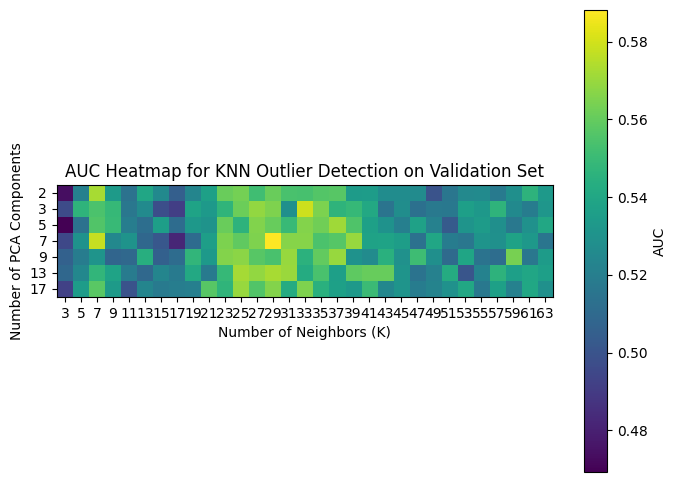

In [23]:
# KNN
# dataset: Annthyroid_norm_02_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Annthyroid\\Annthyroid_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 17]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 5440
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.6238825031928481
Best k (Number of Neighbors): 23
Best n_components (PCA): 9


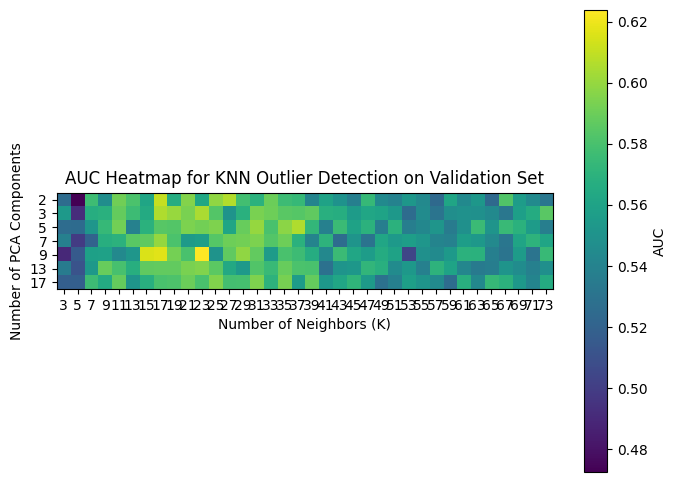

In [24]:
# KNN
# dataset: Annthyroid_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Annthyroid\\Annthyroid_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 17]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [2]:
# KNN
# dataset: Arrhythmia_withoutdupl_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Arrhythmia\\Arrhythmia_withoutdupl_norm_02_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 13, 15, 25, 35]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.9591836734693878


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Number of training samples: 148
Testing K values: [3, 5, 7, 9, 11]


C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

Maximum AUC on Validation Set: 0.8673469387755102
Best k (Number of Neighbors): 9
Best n_components (PCA): 2


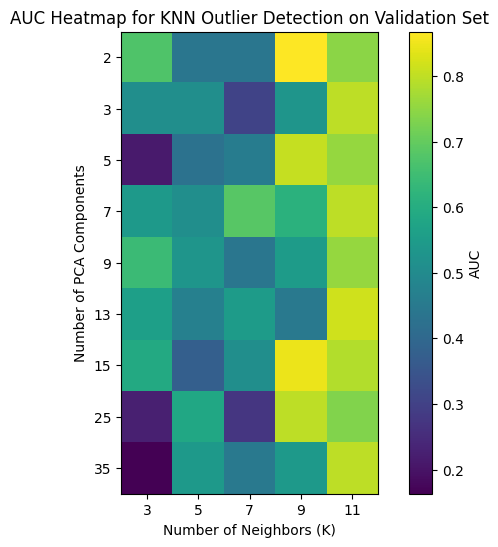

In [7]:
# KNN
# dataset: Arrhythmia_withoutdupl_norm_02_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Arrhythmia\\Arrhythmia_withoutdupl_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 25, 35]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 197
Testing K values: [3, 5, 7, 9, 11, 13]


C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

Maximum AUC on Validation Set: 0.9591836734693877
Best k (Number of Neighbors): 7
Best n_components (PCA): 2


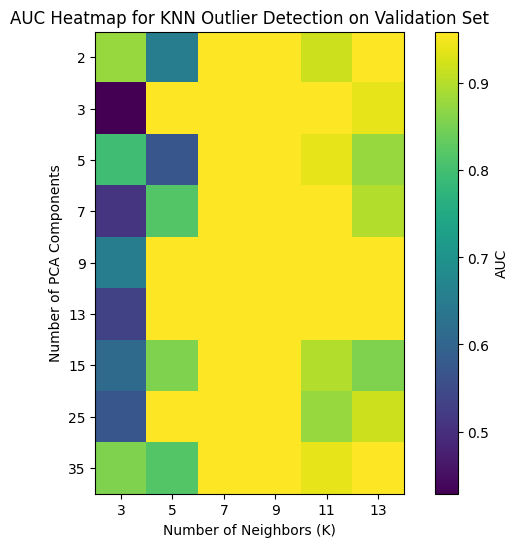

In [8]:
# KNN
# dataset: Arrhythmia_withoutdupl_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Arrhythmia\\Arrhythmia_withoutdupl_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 25, 35]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [3]:
# KNN
# dataset: Cardiotocography_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Cardiotocography\\Cardiotocography_norm_02_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 13, 17]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.9527610441767068


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()


Number of training samples: 1012
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]


C:\Users\asus\AppData\Local\Temp\ipykernel_7576\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_7576\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

Maximum AUC on Validation Set: 0.923076923076923
Best k (Number of Neighbors): 21
Best n_components (PCA): 2


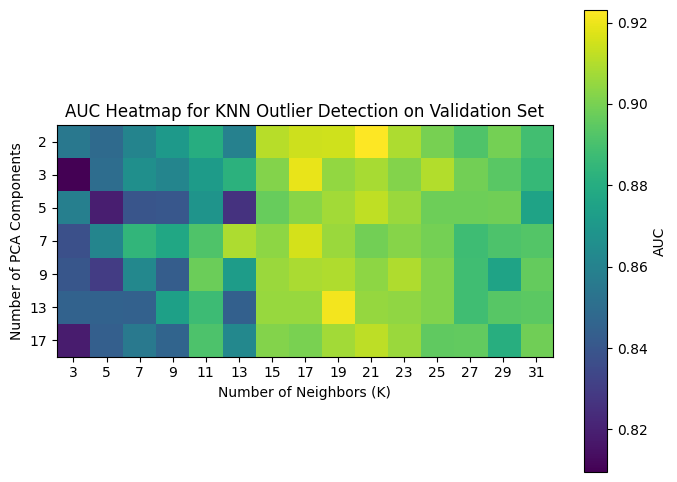

In [3]:
# KNN
# dataset: Cardiotocography_norm_02_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Cardiotocography\\Cardiotocography_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 17]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 1349
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]


C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_3296\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

Maximum AUC on Validation Set: 0.9568273092369478
Best k (Number of Neighbors): 7
Best n_components (PCA): 7


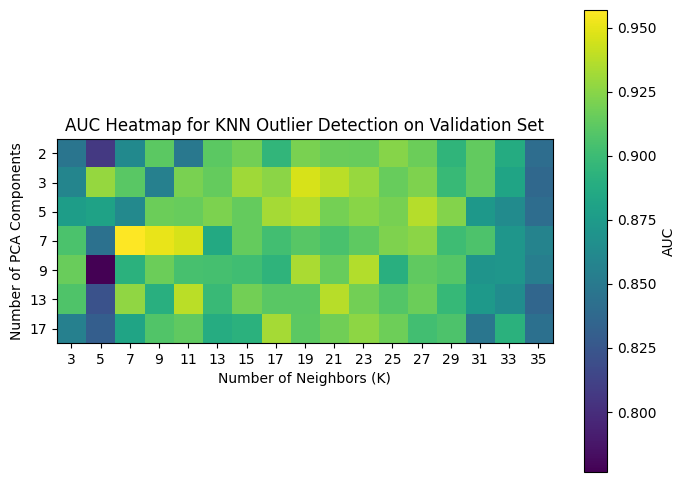

In [6]:
# KNN
# dataset: Cardiotocography_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Cardiotocography\\Cardiotocography_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 17]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [4]:
# KNN
# dataset: HeartDisease_withoutdupl_norm_05_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\HeartDisease\\HeartDisease_withoutdupl_norm_05_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 11, 13]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_6160\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_6160\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

Average of Best AUC over 10 Runs: 0.7225806451612904


C:\Users\asus\AppData\Local\Temp\ipykernel_6160\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_6160\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid thi

In [10]:
# KNN
# dataset: HeartDisease_withoutdupl_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\HeartDisease\\HeartDisease_withoutdupl_norm_02_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.3, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 11, 13]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.9244444444444445


C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Number of training samples: 93
Testing K values: [3, 5, 7, 9]


C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.680327868852459
Best k (Number of Neighbors): 5
Best n_components (PCA): 3


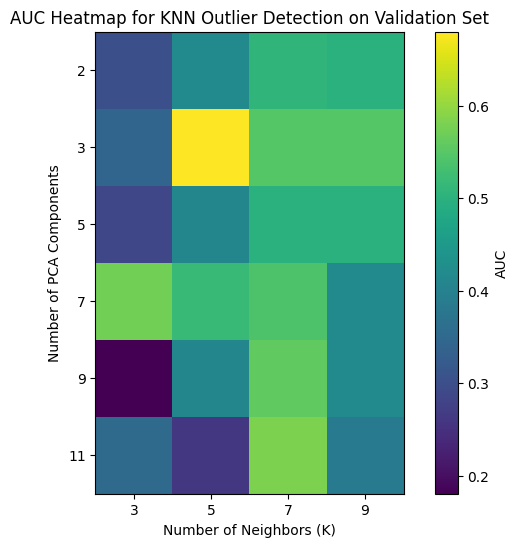

In [4]:
# KNN
# dataset: HeartDisease_withoutdupl_norm_05_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\HeartDisease\\HeartDisease_withoutdupl_norm_05_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 124
Testing K values: [3, 5, 7, 9, 11]


C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_13512\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.7741935483870968
Best k (Number of Neighbors): 9
Best n_components (PCA): 9


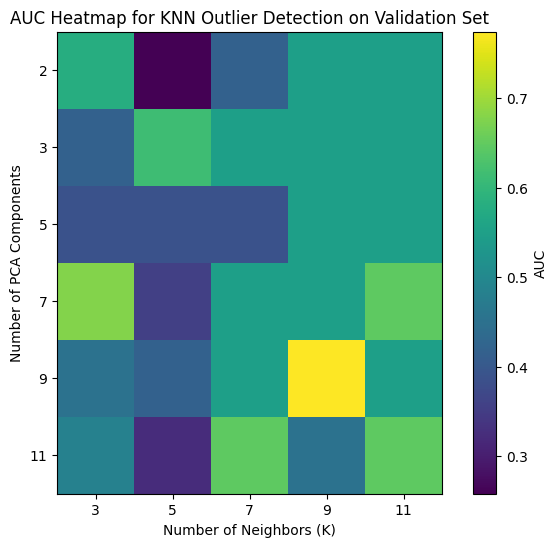

In [3]:
# KNN
# dataset: HeartDisease_withoutdupl_norm_05_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\HeartDisease\\HeartDisease_withoutdupl_norm_05_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [5]:
# KNN
# dataset: Hepatitis_withoutdupl_norm_05_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Hepatitis\\Hepatitis_withoutdupl_norm_05_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 11] # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.9230769230769231


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), th

Number of training samples: 41
Testing K values: [3, 5, 7, 9]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.8518518518518519
Best k (Number of Neighbors): 7
Best n_components (PCA): 3


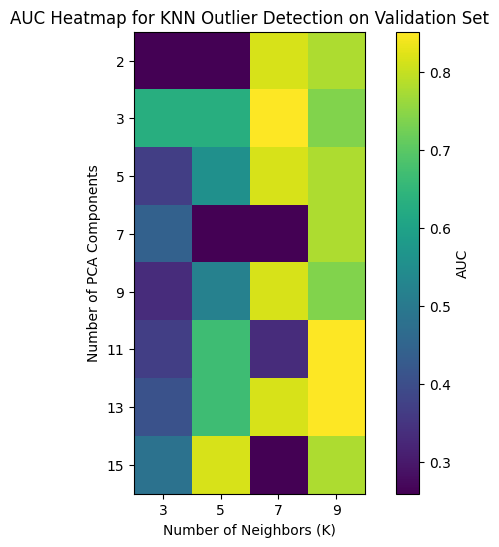

In [2]:
# KNN
# dataset: Hepatitis_withoutdupl_norm_05_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Hepatitis\\Hepatitis_withoutdupl_norm_05_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values
k_values.append(7)
k_values.append(9)
print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11, 13, 15]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 55
Testing K values: [3, 5, 7, 7, 9]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.9230769230769231
Best k (Number of Neighbors): 5
Best n_components (PCA): 2


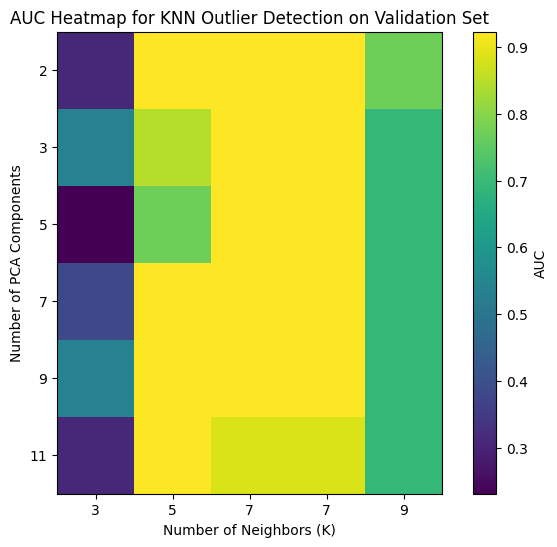

In [19]:
# KNN
# dataset: Hepatitis_withoutdupl_norm_05_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Hepatitis\\Hepatitis_withoutdupl_norm_05_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values
k_values.append(7)
k_values.append(9)
print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 11]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                           (results['k'] == k)]['auc'].mean()

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [6]:
# KNN
# dataset: Lymphography_withoutdupl_norm_1ofn.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Lymphography\\Lymphography_withoutdupl_norm_1ofn.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-2].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -2].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 9, 13, 15, 21]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 1.0


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()


Number of training samples: 88
Testing K values: [3, 5, 7, 9]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 1.0
Best k (Number of Neighbors): 7
Best n_components (PCA): 5


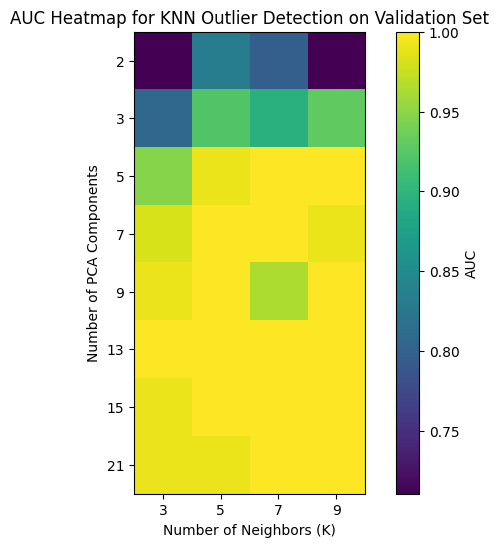

In [10]:
# KNN
# dataset: Lymphography_withoutdupl_norm_1ofn.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Lymphography\\Lymphography_withoutdupl_norm_1ofn.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-2].values

# Separate labels (last column)
labels = df.iloc[:, -2].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 21]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 117
Testing K values: [3, 5, 7, 9]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 1.0
Best k (Number of Neighbors): 9
Best n_components (PCA): 2


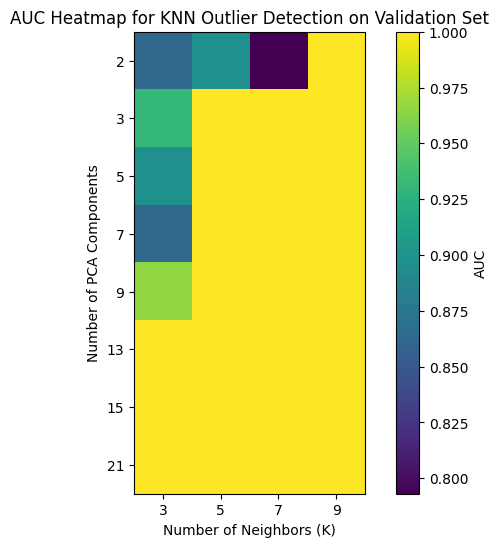

In [11]:
# KNN
# dataset: Lymphography_withoutdupl_norm_1ofn.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Lymphography\\Lymphography_withoutdupl_norm_1ofn.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-2].values

# Separate labels (last column)
labels = df.iloc[:, -2].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13, 15, 21]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [8]:
# KNN
# dataset: Parkinson_withoutdupl_norm_10_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Parkinson\\Parkinson_withoutdupl_norm_10_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 1.0


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
c:\Users\asus\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), th

Number of training samples: 31
Testing K values: [3, 5]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.9473684210526316
Best k (Number of Neighbors): 3
Best n_components (PCA): 3


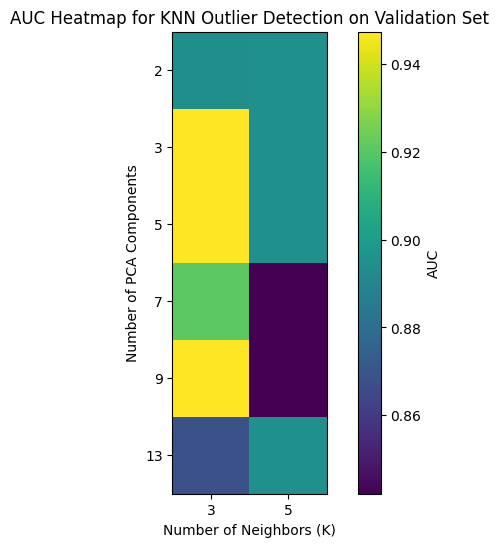

In [12]:
# KNN
# dataset: Parkinson_withoutdupl_norm_10_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Parkinson\\Parkinson_withoutdupl_norm_10_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 9, 13]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 41
Testing K values: [3, 5]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 1.0
Best k (Number of Neighbors): 3
Best n_components (PCA): 2


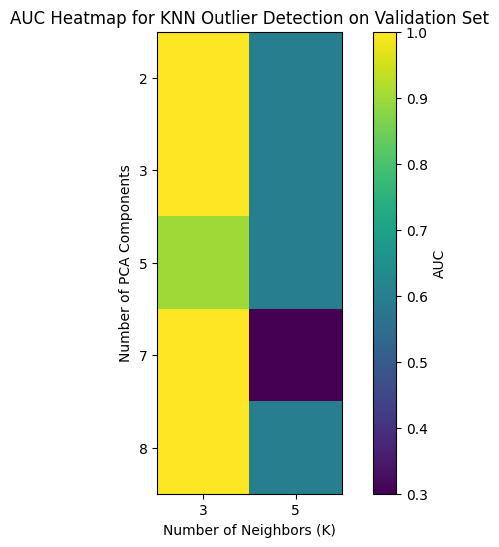

In [13]:
# KNN
# dataset: Parkinson_withoutdupl_norm_10_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Parkinson\\Parkinson_withoutdupl_norm_10_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values

print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


In [9]:
# KNN
# dataset: Pima_withoutdupl_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Pima\\Pima_withoutdupl_norm_02_v01.csv"

def run_knn_experiment():
    # Load the CSV file into a Pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Separate data (all columns except the last)
    data = df.iloc[:, :-1].values
    
    # Separate labels (last column)
    labels = df.iloc[:, -1].values
    
    # Split the data into training and validation sets (80% train, 20% validation)
    X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)
    
    # Dynamically calculate odd K values based on the training set size
    N_train = len(X_train)
    max_k = int(math.sqrt(N_train))
    k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]
    
    # Define the hyperparameter ranges
    n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components
    
    # To store grid search results
    results = []
    
    for n_components in n_components_values:
        for k in k_values:
            # Calculate KNN outlier scores on the training set
            predicted_labels, outlier_scores = calculate_knn_outlier_scores(
                X_train, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance on the validation set
            val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
                X_val, n_samples=5, sample_fraction=0.8,
                n_components=n_components, n_neighbors=k, contamination=0.1
            )
            
            # Evaluate the performance
            precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
            
            # Store results (n_components, k, precision, recall, auc)
            results.append((n_components, k, precision, recall, auc))
    
    # Convert results to a structured array for analysis
    results = np.array(results, dtype=[('n_components', int), ('k', int), ('precision', float), ('recall', float), ('auc', float)])
    
    # Find the best parameters based on the maximum AUC
    max_auc_index = np.argmax(results['auc'])
    return results['auc'][max_auc_index]

# Run the experiment 10 times
best_auc_values = [run_knn_experiment() for _ in range(10)]

# Compute the average of the best AUC values
mean_best_auc = np.mean(best_auc_values)
print(f"Average of Best AUC over 10 Runs: {mean_best_auc}")


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Average of Best AUC over 10 Runs: 0.8725000000000002


C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_10396\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Number of training samples: 305
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.77125
Best k (Number of Neighbors): 3
Best n_components (PCA): 8


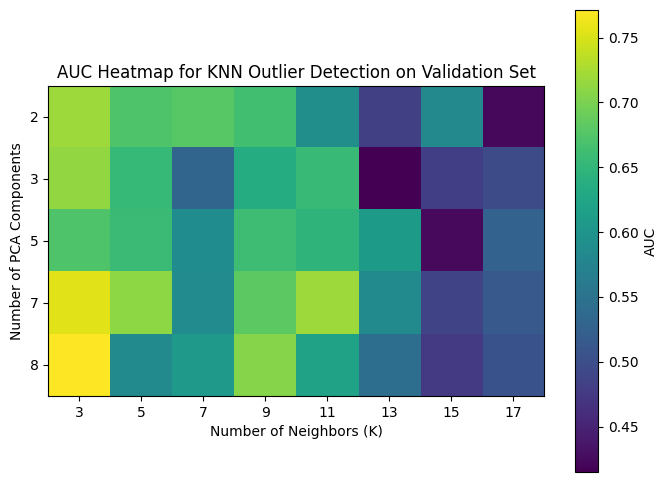

In [14]:
# KNN
# dataset: Pima_withoutdupl_norm_02_v01.csv
# 60 40
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Pima\\Pima_withoutdupl_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (60% train, 40% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.4, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values
print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()


Number of training samples: 407
Testing K values: [3, 5, 7, 9, 11, 13, 15, 17, 19]


C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  final_labels = mode(all_labels, axis=0)[0].flatten()
C:\Users\asus\AppData\Local\Temp\ipykernel_14256\1477799171.py:51: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid t

Maximum AUC on Validation Set: 0.85
Best k (Number of Neighbors): 5
Best n_components (PCA): 7


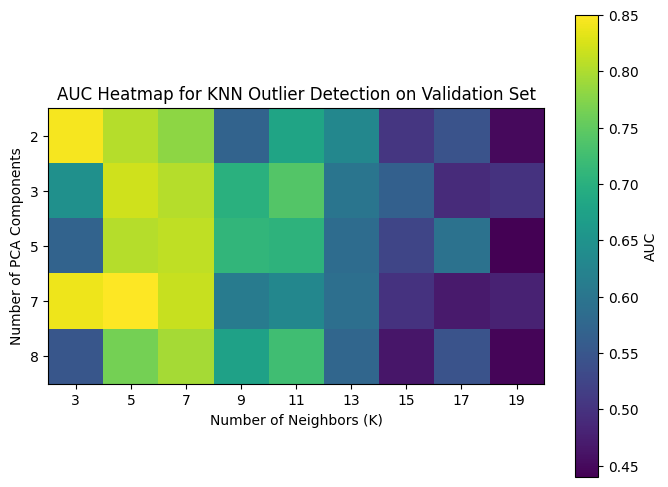

In [15]:
# KNN
# dataset: Pima_withoutdupl_norm_02_v01.csv
# 80 20
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# File path to the dataset
file_path = "G:\\Nazanin\\B project\\code\\dataset\\Pima\\Pima_withoutdupl_norm_02_v01.csv"

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

# Separate data (all columns except the last)
data = df.iloc[:, :-1].values

# Separate labels (last column)
labels = df.iloc[:, -1].values

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Dynamically calculate odd K values based on the training set size
N_train = len(X_train)  # Number of training samples
max_k = int(math.sqrt(N_train))  # sqrt(N) for the training set
k_values = [k for k in range(3, max_k + 1) if k % 2 == 1]  # Odd K values
print("Number of training samples:", N_train)
print("Testing K values:", k_values)

# Define the hyperparameter ranges
n_components_values = [2, 3, 5, 7, 8]  # Number of PCA components

# To store grid search results
results = []

# Perform grid search on the training set
for n_components in n_components_values:
    for k in k_values:
        # Calculate KNN outlier scores on the training set
        predicted_labels, outlier_scores = calculate_knn_outlier_scores(
            X_train, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance on the validation set
        val_predicted_labels, val_outlier_scores = calculate_knn_outlier_scores(
            X_val, n_samples=5, sample_fraction=0.8,
            n_components=n_components, n_neighbors=k, contamination=0.1
        )
        
        # Evaluate the performance
        precision, recall, auc = evaluate_knn_outlier_detection(y_val, val_predicted_labels, val_outlier_scores)
        
        # Store results (n_components, k, precision, recall, auc)
        results.append((n_components, k, precision, recall, auc))

# Convert results to a structured array for analysis
results = np.array(results, dtype=[('n_components', int), ('k', int), 
                                    ('precision', float), ('recall', float), ('auc', float)])

# Find the best parameters based on the maximum AUC
max_auc_index = np.argmax(results['auc'])
max_auc = results['auc'][max_auc_index]
best_k = results['k'][max_auc_index]
best_n_components = results['n_components'][max_auc_index]

# Print the best results
print(f"Maximum AUC on Validation Set: {max_auc}")
print(f"Best k (Number of Neighbors): {best_k}")
print(f"Best n_components (PCA): {best_n_components}")

# Visualize the results: Heatmap for AUC
auc_matrix = np.zeros((len(n_components_values), len(k_values)))

# Fill the matrix with AUC scores
for i, n_components in enumerate(n_components_values):
    for j, k in enumerate(k_values):
        auc_matrix[i, j] = results[(results['n_components'] == n_components) & 
                                   (results['k'] == k)]['auc']

# Plot heatmap
plt.figure(figsize=(8, 6))
plt.imshow(auc_matrix, interpolation='nearest', cmap='viridis')
plt.colorbar(label='AUC')
plt.xticks(np.arange(len(k_values)), labels=k_values)
plt.yticks(np.arange(len(n_components_values)), labels=n_components_values)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Number of PCA Components')
plt.title('AUC Heatmap for KNN Outlier Detection on Validation Set')
plt.show()
